### Market Analysis on E-commerce Data 

In [144]:
import pandas as pd ## data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np ## linear algebra
import matplotlib.pyplot as plt ## plotting
import seaborn as sns ## plotting
import datetime as dt


In [145]:
# Display Handling
import warnings
warnings.filterwarnings("ignore")

# Make charts looks better
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

import os
print(os.getcwd())


print("✅ All libraries imported successfully!")

c:\Users\Pranay\Desktop\Kaggle\E_commerce_Data
✅ All libraries imported successfully!


In [146]:
## Load the dataset
df = pd.read_csv(r'c:\Users\Pranay\Desktop\Kaggle\E_commerce_Data\data.csv', encoding='latin1')
print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


In [147]:
# ── First Look ──────────────────────────────────

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.00,United Kingdom


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [149]:
# Check shape — how many rows and columns
df.shape

(541909, 8)

In [150]:
# Check data types of each column
df.dtypes


InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [151]:
# Check missing values in each column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [152]:
# Check basic statistics — min, max, mean
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.00,541909.00,406829.00
mean,9.55,4.61,15287.69
std,218.08,96.76,1713.60
min,-80995.00,-11062.06,12346.00
25%,1.00,1.25,13953.00
50%,3.00,2.08,15152.00
75%,10.00,4.13,16791.00
max,80995.00,38970.00,18287.00


#### Data Cleaning

In [153]:
#convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')
print(df['InvoiceDate'].dtype)

datetime64[ns]


In [154]:
#Drop rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])
print(f"Rows after dropping missing CustomerID: {df.shape[0]:,}")


Rows after dropping missing CustomerID: 406,829


In [155]:
# Seprate returns ( negative quantity ) into own dataframe
df_returns = df[df['Quantity'] <0]
df = df[df['Quantity'] > 0]

print(f" Normal transcations: {df.shape[0]:,}")
print(f"Returns : {df_returns.shape[0]:,}")

 Normal transcations: 397,924
Returns : 8,905


In [156]:
# Remove rows where unit price is less than or equal to 0
df =df[df['UnitPrice'] > 0]

print(f"Rows after removing zero or negative unit price: {df.shape[0]:,}")


Rows after removing zero or negative unit price: 397,884


In [157]:
# Remove duplicates 
df = df.drop_duplicates()

print(f"Rows after Removing Duplicates: {df.shape[0]:,}")

Rows after Removing Duplicates: 392,692


In [158]:
# Add total price column

df['Totalprice'] =df["Quantity"] * df["UnitPrice"]

print(df[['Quantity', 'UnitPrice', 'Totalprice']].head())

   Quantity  UnitPrice  Totalprice
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34


In [159]:
# Verify cleaning worked correctly
# Check shape, missing values and min values

print(df.shape)
print(df.isnull().sum())
print(df[["Quantity", "UnitPrice"]].min())


(392692, 9)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Totalprice     0
dtype: int64
Quantity    1.00
UnitPrice   0.00
dtype: float64


### Check what years are in Data 


In [160]:
df['InvoiceDate'].dt.year.unique()

array([2010, 2011])

#### Find most sold product

In [161]:
# Filter transactions for year 2011
df_2011 =df[df['InvoiceDate'].dt.year == 2011 ]

# Group by product name and sum quantities
q1 = df_2011.groupby("Description")['Quantity'].sum().sort_values(ascending=False).head(10)
print(q1)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     49180
JUMBO BAG RED RETROSPOT               44022
WHITE HANGING HEART T-LIGHT HOLDER    33095
ASSORTED COLOUR BIRD ORNAMENT         33004
POPCORN HOLDER                        30919
PACK OF 72 RETROSPOT CAKE CASES       30098
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                23376
Name: Quantity, dtype: int64


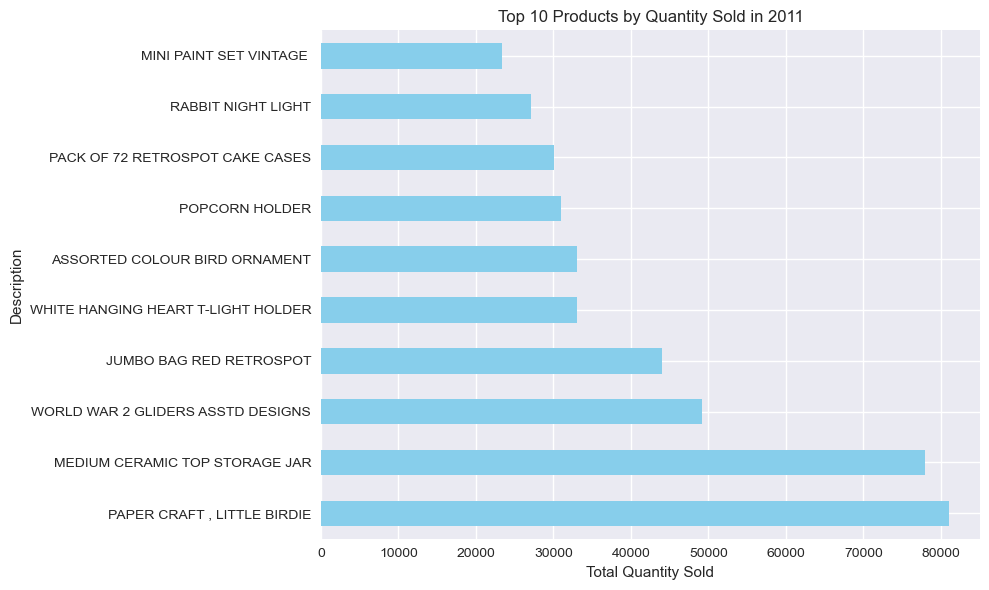

In [162]:
#plot top 10 products by quantity sold in 2011
plt.figure(figsize=(10,6))
q1.plot(kind='barh', color = 'skyblue')
plt.title("Top 10 Products by Quantity Sold in 2011")
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

In [163]:
# Which Country sold most product

q2 = df.groupby("Country")["Quantity"].sum().sort_values(ascending=False).head(10)
print(q2)

Country
United Kingdom    4241305
Netherlands        200361
EIRE               140133
Germany            119154
France             111428
Australia           83891
Sweden              36078
Switzerland         30082
Spain               27933
Japan               26016
Name: Quantity, dtype: int64


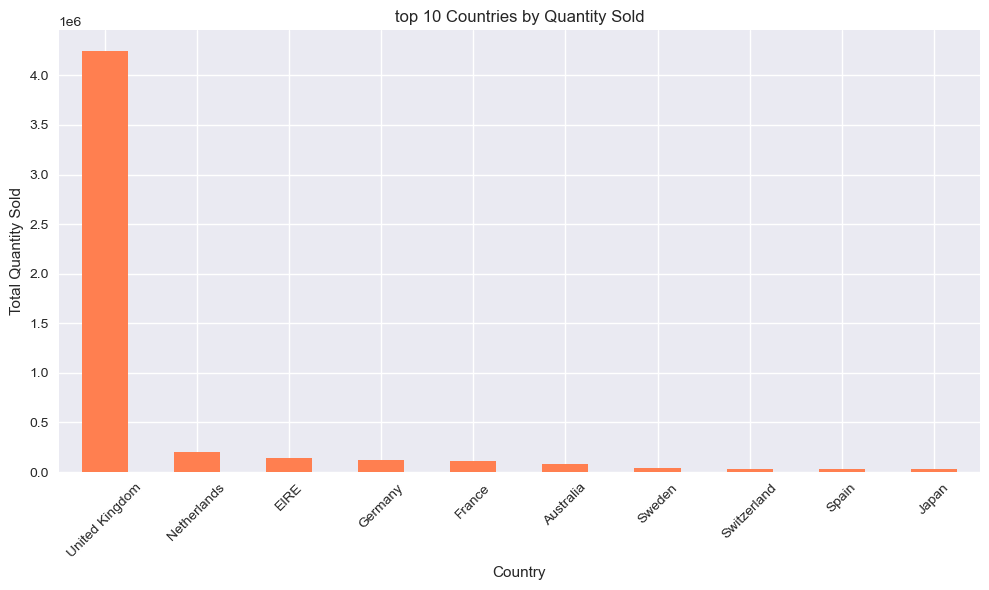

In [164]:
plt.figure(figsize=(10,6))
q2.plot(kind='bar',color='coral')
plt.title("top 10 Countries by Quantity Sold")
plt.xlabel('Country')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Description
PAPER CRAFT , LITTLE BIRDIE          168469.60
REGENCY CAKESTAND 3 TIER             142264.75
WHITE HANGING HEART T-LIGHT HOLDER   100392.10
JUMBO BAG RED RETROSPOT               85040.54
MEDIUM CERAMIC TOP STORAGE JAR        81416.73
POSTAGE                               77803.96
PARTY BUNTING                         68785.23
ASSORTED COLOUR BIRD ORNAMENT         56413.03
Manual                                53419.93
RABBIT NIGHT LIGHT                    51251.24
Name: Totalprice, dtype: float64


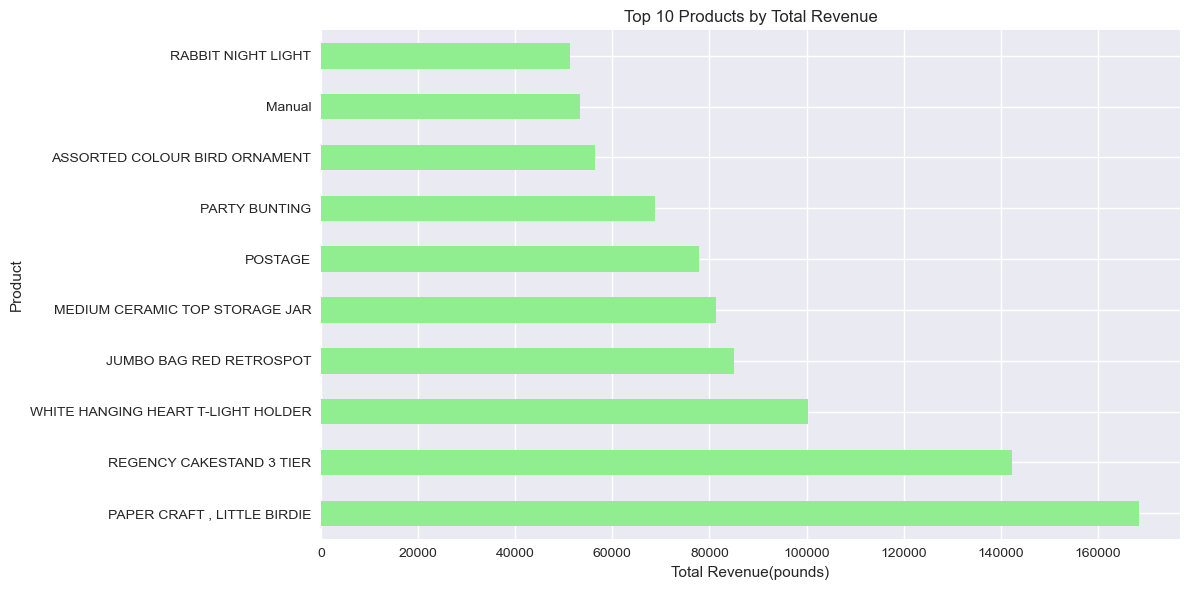

In [165]:
# Which products Generates Most Revenue
q3 = df.groupby("Description")['Totalprice'].sum().sort_values(ascending=False).head(10)
print(q3)

plt.figure(figsize=(12,6))
q3.plot(kind='barh', color='lightgreen')
plt.title("Top 10 Products by Total Revenue")
plt.xlabel('Total Revenue(pounds)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


In [166]:
#Least Sold Products

q4 = df.groupby('Description')['Quantity'].sum()\
       .sort_values(ascending=True)\
       .head(10)
print(q4)

Description
BLOSSOM IMAGES SCRAP BOOK SET          1
PACK 4 FLOWER/BUTTERFLY PATCHES        1
BLACK DROP EARRINGS W LONG BEADS       1
VINTAGE BEAD PINK JEWEL STAND          1
SET/3 FLORAL GARDEN TOOLS IN BAG       1
WHITE ROSEBUD  PEARL EARRINGS          1
WHITE STONE/CRYSTAL EARRINGS           1
SET/3 TALL GLASS CANDLE HOLDER PINK    1
CROCHET DOG KEYRING                    1
CAKE STAND LACE WHITE                  1
Name: Quantity, dtype: int64


In [167]:
# Count total quantity per product 

product_sales = df.groupby('Description')['Quantity'].sum()

#Filter products with total quantity sold less than 1
q4_better =product_sales[product_sales > 1].sort_values(ascending=True).head(10)    
print(q4_better)

Description
PINK/WHITE RIBBED MELAMINE JUG        2
BLUE SHARK HELICOPTER                 2
PINK/WHITE GLASS DEMI CHOKER          2
RUBY GLASS CLUSTER NECKLACE           2
GLASS CAKE COVER AND PLATE            2
NEW BAROQUE B'FLY NECKLACE CRYSTAL    2
NEW BAROQUE B'FLY NECKLACE GREEN      2
WHITE ANEMONE ARTIFICIAL FLOWER       2
PEARL & SHELL 42"NECKL. IVORY         2
SET OF 16 VINTAGE IVORY CUTLERY       2
Name: Quantity, dtype: int64


Month
2010-12    570422.73
2011-01    568101.31
2011-02    446084.92
2011-03    594081.76
2011-04    468374.33
2011-05    677355.15
2011-06    660046.05
2011-07    598962.90
2011-08    644051.04
2011-09    950690.20
2011-10   1035642.45
2011-11   1156205.61
2011-12    517190.44
Freq: M, Name: Totalprice, dtype: float64


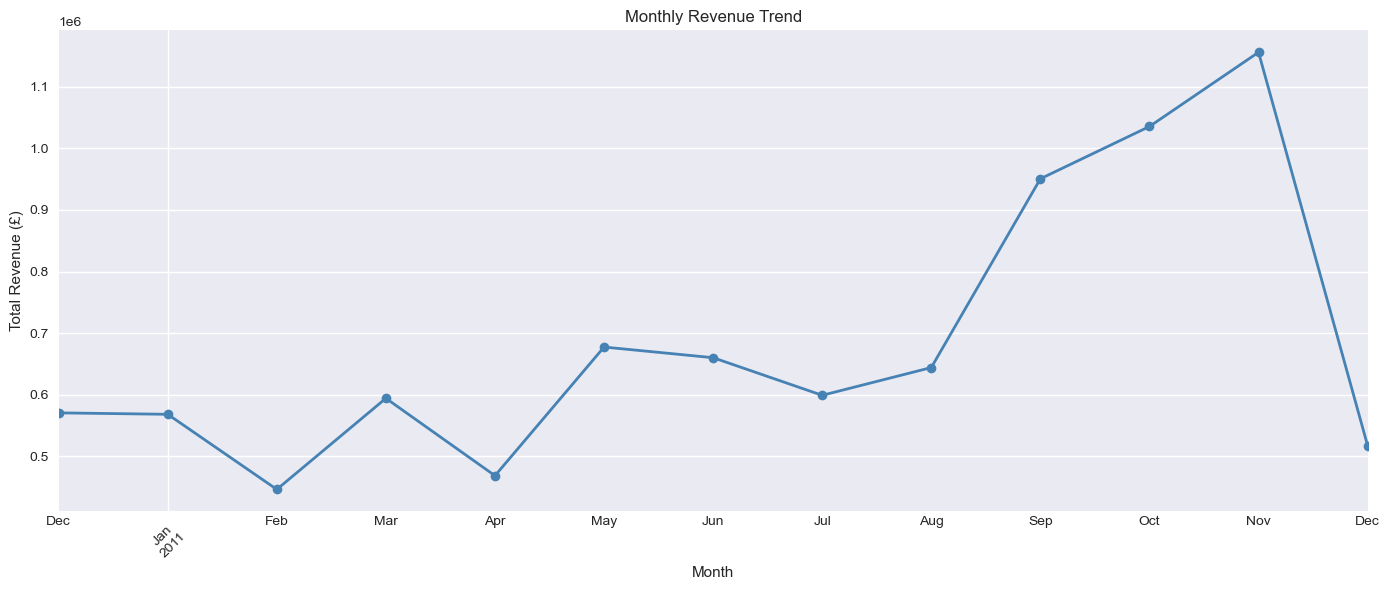

In [168]:
# Monthly Revenue Trend

df['Month']=df['InvoiceDate'].dt.to_period('M') 

q5 = df.groupby('Month')['Totalprice'].sum()
print(q5)

plt.figure(figsize=(14,6))
q5.plot(kind='line', color='steelblue', marker='o', linewidth=2)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [169]:
#Convert to proper time series format
q5_ts = df.groupby('Month')['Totalprice'].sum().reset_index() 
q5_ts['Month']= q5_ts['Month'].dt.to_timestamp()  # Convert Period to Timestamp
q5_ts = q5_ts.set_index('Month')
print(q5_ts)



            Totalprice
Month                 
2010-12-01   570422.73
2011-01-01   568101.31
2011-02-01   446084.92
2011-03-01   594081.76
2011-04-01   468374.33
2011-05-01   677355.15
2011-06-01   660046.05
2011-07-01   598962.90
2011-08-01   644051.04
2011-09-01   950690.20
2011-10-01  1035642.45
2011-11-01  1156205.61
2011-12-01   517190.44


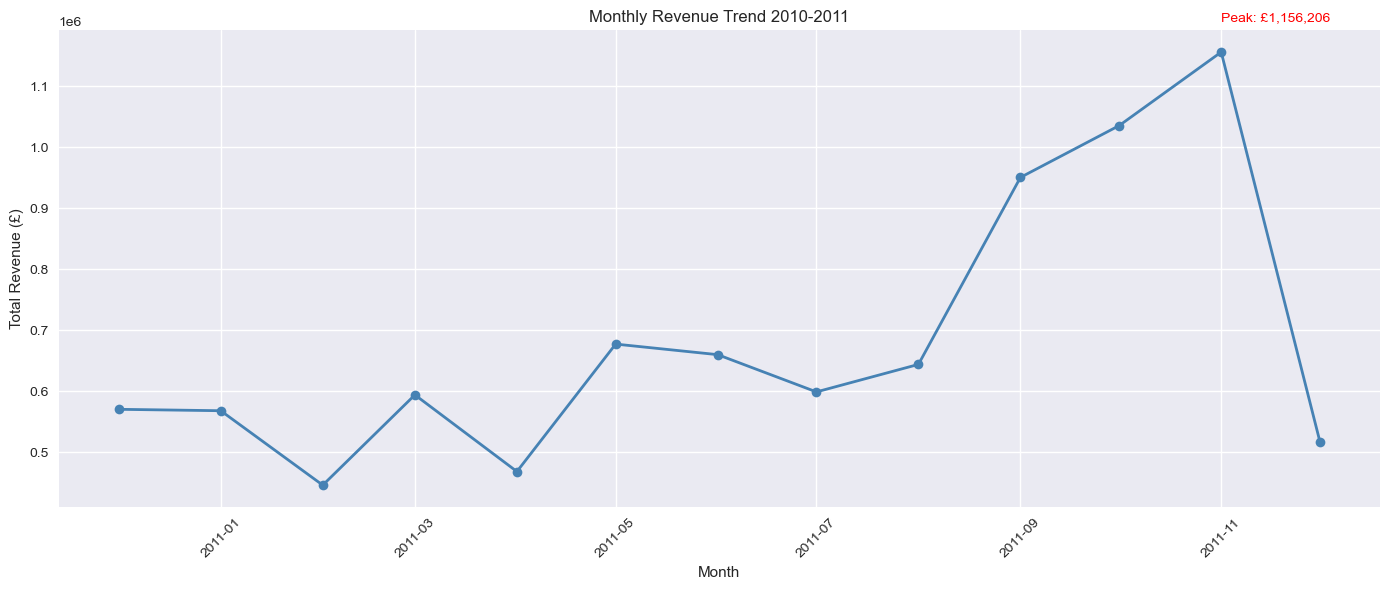

In [170]:

plt.figure(figsize=(14,6))
plt.plot(q5_ts.index, q5_ts['Totalprice'], 
         color='steelblue', 
         marker='o', 
         linewidth=2)

# Add highest point annotation

max_month = q5_ts['Totalprice'].idxmax()
max_value = q5_ts['Totalprice'].max()
plt.annotate(f'Peak: £{max_value:,.0f}', 
             xy=(max_month, max_value),
             xytext=(max_month, max_value + 50000),
             fontsize=10,
             color='red')

plt.title('Monthly Revenue Trend 2010-2011')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

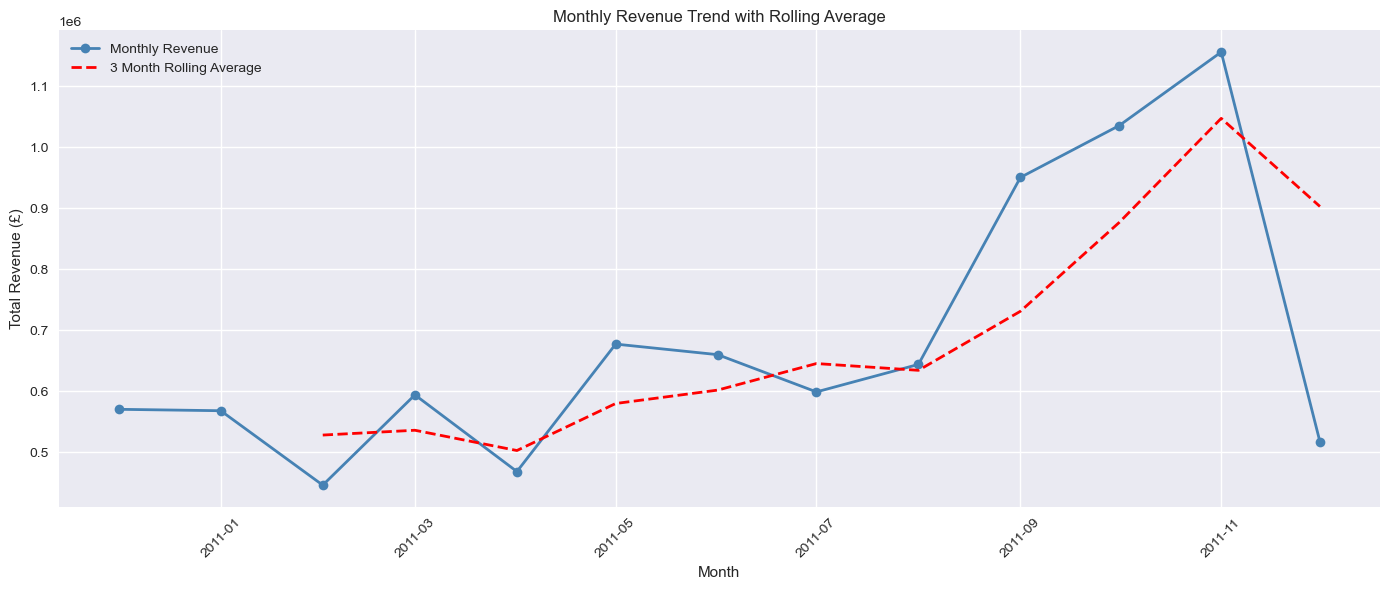

In [171]:
# Rolling average smooths out the line
q5_ts['Rolling_3M'] = q5_ts['Totalprice'].rolling(window=3).mean()

plt.figure(figsize=(14,6))

# Actual revenue
plt.plot(q5_ts.index, q5_ts['Totalprice'],
         color='steelblue',
         marker='o',
         linewidth=2,
         label='Monthly Revenue')

# Rolling average
plt.plot(q5_ts.index, q5_ts['Rolling_3M'],
         color='red',
         linewidth=2,
         linestyle='--',
         label='3 Month Rolling Average')

plt.title('Monthly Revenue Trend with Rolling Average')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CustomerID
14646.00   280206.02
18102.00   259657.30
17450.00   194390.79
16446.00   168472.50
14911.00   143711.17
12415.00   124914.53
14156.00   117210.08
17511.00    91062.38
16029.00    80850.84
12346.00    77183.60
Name: Totalprice, dtype: float64


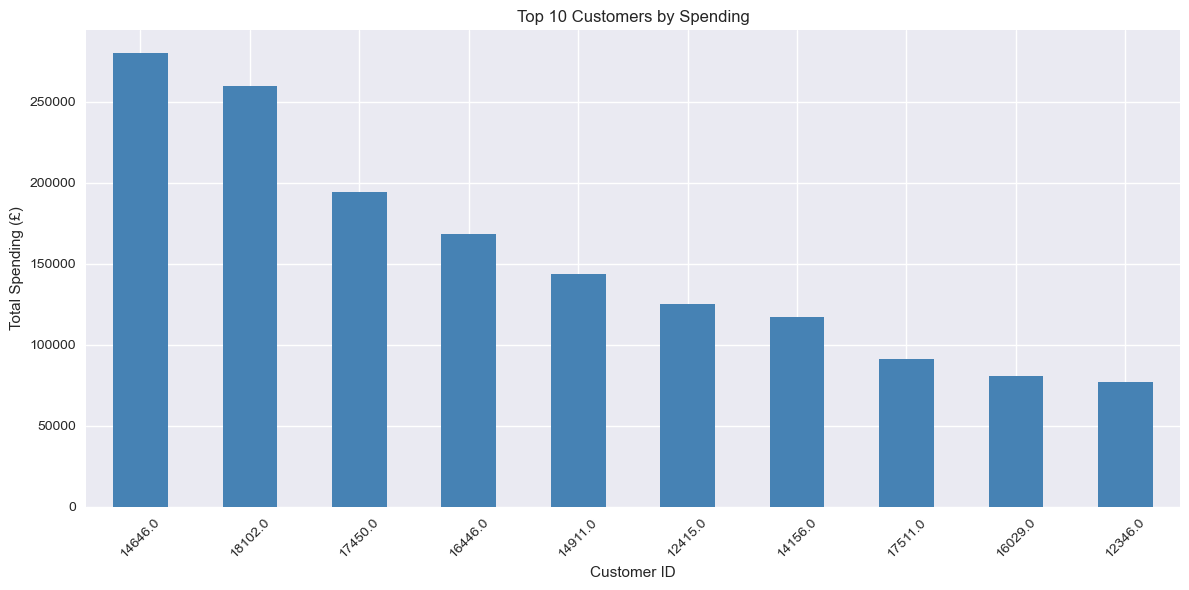

In [172]:
# Who are the top 10 customers by total spending?



q6 = df.groupby('CustomerID')['Totalprice'].sum().sort_values(ascending=False).head(10)
print(q6)

plt.figure(figsize=(12,6))
q6.plot(kind='bar', color='steelblue')
plt.title('Top 10 Customers by Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

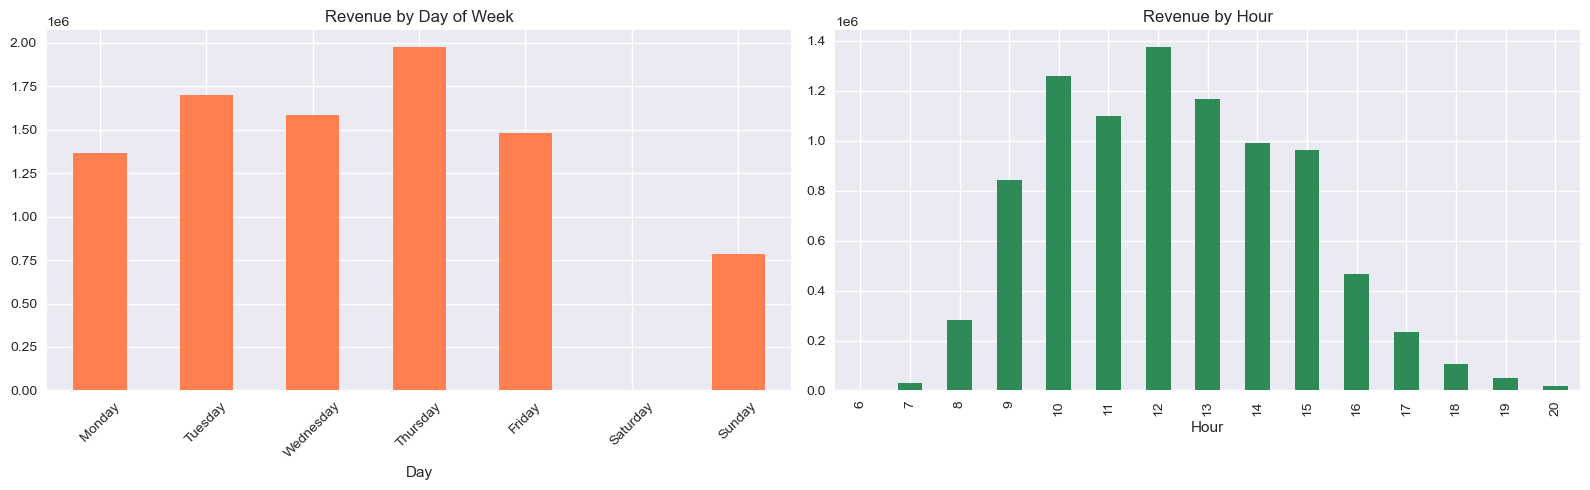

In [173]:
#Days and Hours Analysis.
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16,5))

df.groupby('DayOfWeek')['Totalprice'].sum()\
  .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])\
  .plot(kind='bar', color='coral', ax=axes[0])
axes[0].set_title('Revenue by Day of Week')
axes[0].set_xlabel('Day')
axes[0].tick_params(axis='x', rotation=45)

df.groupby('Hour')['Totalprice'].sum()\
  .plot(kind='bar', color='seagreen', ax=axes[1])
axes[1].set_title('Revenue by Hour')
axes[1].set_xlabel('Hour')

plt.tight_layout()
plt.show()

Total Transactions : 392,692
Total Returns      : 8,905
Returns %          : 2.3%


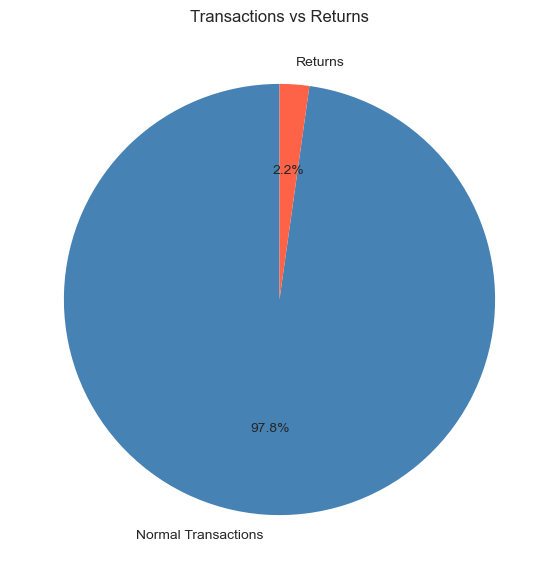

In [174]:
total = len(df)
returns = len(df_returns)
pct = (returns / total) * 100

print(f"Total Transactions : {total:,}")
print(f"Total Returns      : {returns:,}")
print(f"Returns %          : {pct:.1f}%")

labels = ['Normal Transactions', 'Returns']
sizes = [total, returns]
colors = ['steelblue', 'tomato']

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90)
plt.title('Transactions vs Returns')
plt.show()

In [175]:
# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')

# Verify
print(df['InvoiceDate'].dtype)
print(df['InvoiceDate'].head())

# Snapshot date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(snapshot_date)

datetime64[ns]
0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]
2011-12-10 12:50:00


In [176]:
# Calculate RFM for each customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate' : lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo'   : 'nunique',
    'Totalprice'  : 'sum'
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
print(rfm.head(10))

   CustomerID  Recency  Frequency  Monetary
0    12346.00      326          1  77183.60
1    12347.00        2          7   4310.00
2    12348.00       75          4   1797.24
3    12349.00       19          1   1757.55
4    12350.00      310          1    334.40
5    12352.00       36          8   2506.04
6    12353.00      204          1     89.00
7    12354.00      232          1   1079.40
8    12355.00      214          1    459.40
9    12356.00       23          3   2811.43


In [177]:
#Scale the data 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
print("Scaling done!")


Scaling done!


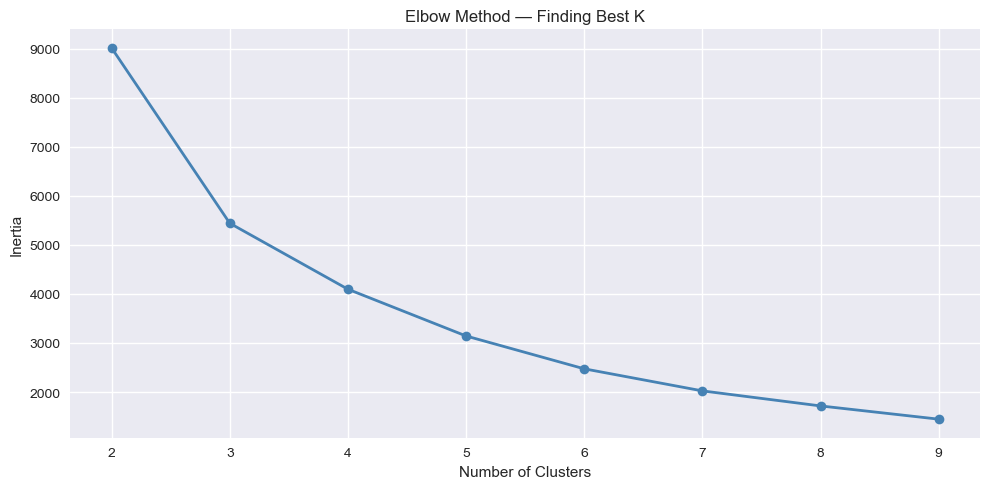

In [178]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2,10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10,5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Finding Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [179]:
#Run KMeans with k=4

km = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = km.fit_predict(rfm_scaled)
print(rfm['Cluster'].value_counts())


Cluster
3    3052
0    1062
1     211
2      13
Name: count, dtype: int64


In [180]:
# Labels the Clusters

rfm['Segment'] = rfm['Cluster'].map({
    0: 'Lost Customers',
    1: 'VIP Customers',
    2: 'Regular Customers',
    3: 'At Risk Customers'
})
print(rfm['Segment'].value_counts())

Segment
At Risk Customers    3052
Lost Customers       1062
VIP Customers         211
Regular Customers      13
Name: count, dtype: int64


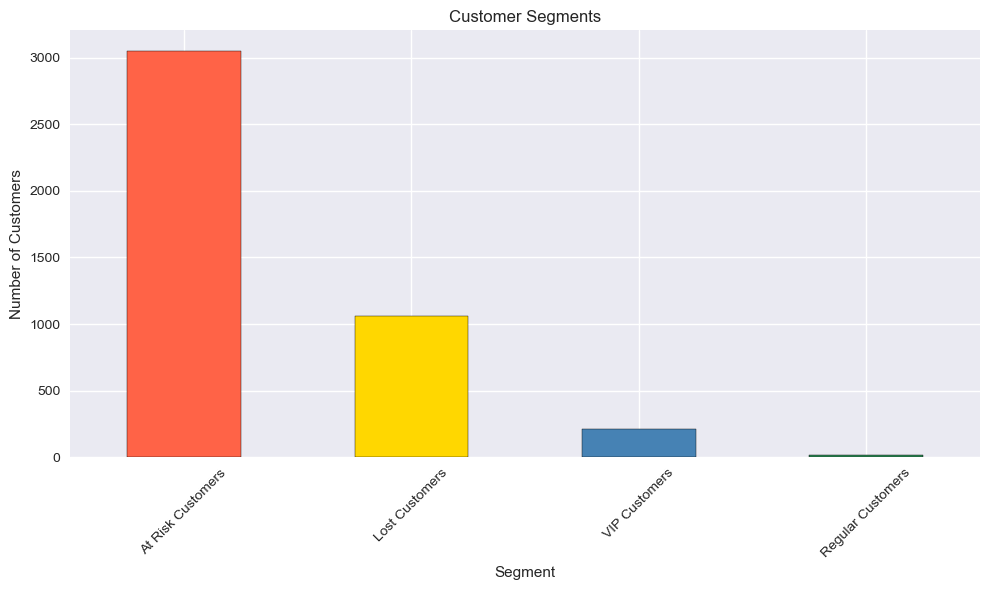

In [181]:
# Visualize the segments

plt.figure(figsize=(10,6))
colors = ['tomato', 'gold', 'steelblue', 'seagreen']

rfm['Segment'].value_counts().plot(
    kind='bar',
    color=colors,
    edgecolor='black'
)

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [182]:
#Segment Summary

print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2))

                   Recency  Frequency  Monetary
Segment                                        
At Risk Customers    43.92       3.66   1344.72
Lost Customers      248.56       1.55    476.33
Regular Customers     7.38      82.54 127187.96
VIP Customers        15.67      22.05  12435.09



## 📋 Key Findings & Business Insights

### Products
- Top selling product by volume is WORLD WAR 2 GLIDERS ASSTD DESIGNS
- Top revenue generating product differs from top volume product
- Several products sold only 2-3 units — dead stock to be removed

### Geography
- UK generates 85% of all revenue — high market concentration risk
- Netherlands is the strongest international market
- Opportunity to expand in Germany and France

### Time Patterns
- November 2011 was peak revenue month — Christmas seasonality
- Thursday is the busiest day for transactions
- 12pm is the peak hour — lunch time shopping

### Customers
- Top customer spent £280,206 — extremely high value
- Returns rate is only 2.2% — well below industry average of 5-10%

### Customer Segments
- VIP Customers     :   13 customers → avg spend £127,187
- Loyal Customers   :  211 customers → avg spend £12,435
- Regular Customers : 3052 customers → avg spend £1,344
- Lost Customers    : 1062 customers → last bought 8 months ago
```